# Moment-bounded ETAS — exploration

First look at the simulator: run a multi-century catalog and inspect the §9 behaviors —
magnitude-frequency, the moment-field sawtooth, depletion holes, and the supportable-Mmax map.
See `../spec.md` for the model.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from moment_etas import Params, simulate_catalog
from moment_etas.visualization import plots
from moment_etas.model.rupture import moment

params = Params()
params

Params(m_min=3.0, b=1.0, lx=100.0, ly=100.0, cell=1.0, f0=2e+16, mdot=500000000000.0, a0=0.1, mu0=1e-06, k=0.05, alpha=1.0, c=0.01, p=1.2, d_km=1.0, gamma=0.5, q=1.8)

## Run

300 years on the default 100×100 km domain. Defaults: initial field supports ~M6.5;
loading recharges that level in ~100 yr.

In [2]:
cat = simulate_catalog(params, t_max=300 * 365.25, seed=11)

bg = (cat.parent == -1).sum()
print(f"{len(cat)} events ({bg} background, {len(cat) - bg} triggered), "
      f"{cat.n_locked} locked discards")
print(f"largest event: M{cat.m.max():.1f}")

# moment accounting (spec §9): grid depletion vs released moment (<= 1, edge clipping only)
dep = cat.field.depletion.sum() * cat.field.cell_area
print(f"accounting ratio: {dep / moment(cat.m).sum():.4f}")

1496 events (1052 background, 444 triggered), 0 locked discards
largest event: M6.3
accounting ratio: 0.9968


## Overview

Catalog timeline, space-time diagram, magnitude-frequency vs the input GR slope, and the
field sawtooth at the largest event's epicenter (linear recharge, sharp drop at rupture).

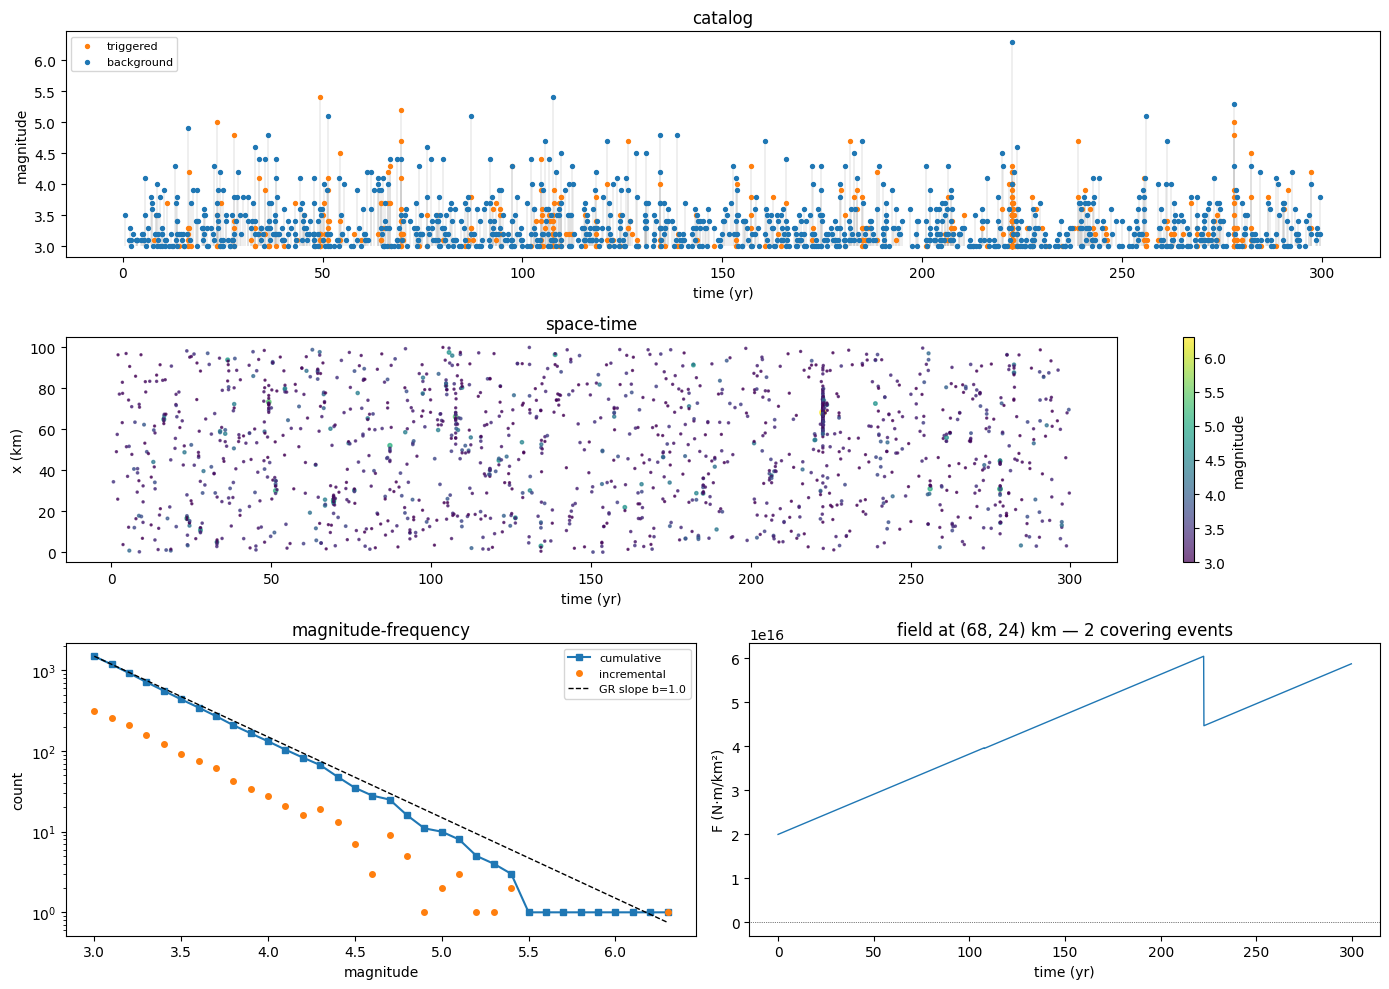

In [3]:
fig = plots.overview(cat)

## Field state and supportable Mmax

Left: the moment density field at the end of the run — rupture-disk "holes" punched by the
largest events into the charged background.

Right: the local Mmax from the supportability scan. Note the **edge effect**: rupture disks
are clipped at the domain boundary, so less moment is enclosed there and the supportable
magnitude drops toward the edges (spec §5.1 — keep the domain larger than the analysis
region).

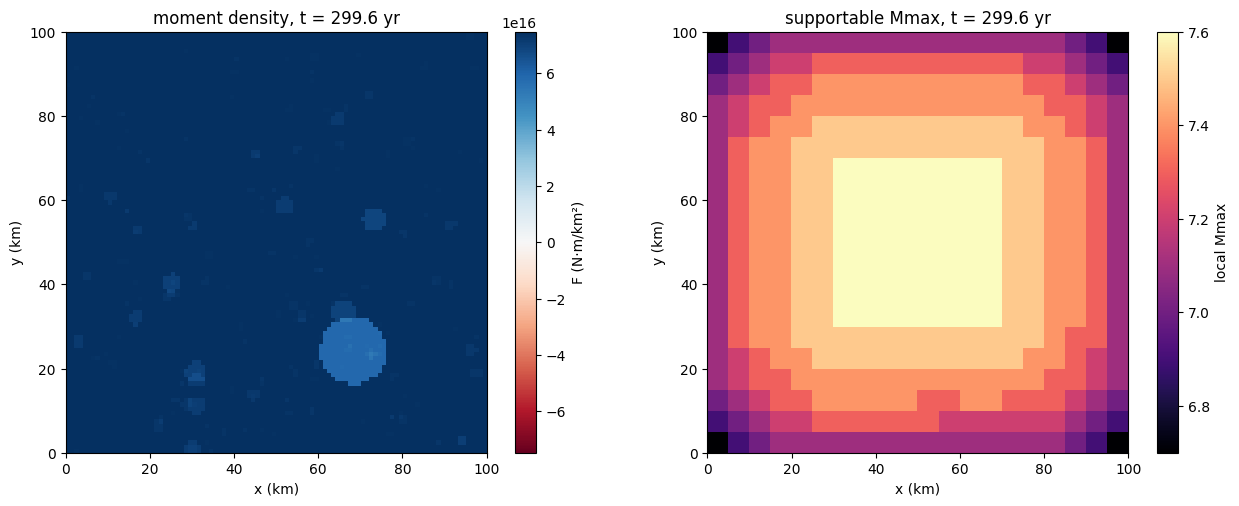

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plots.field_map(cat, ax=axes[0])
plots.mmax_map(cat, coarse=5, ax=axes[1])
fig.tight_layout()

## Epicenters

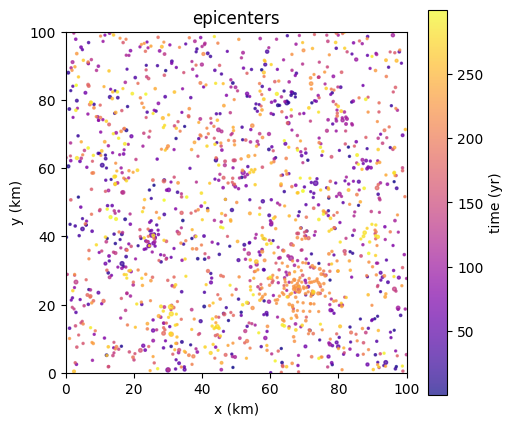

In [5]:
plots.epicenter_map(cat);

## Things to look at next

- **Sawtooth / recovery staircase**: time to re-support magnitude M after a drain scales like
  $10^{0.5M}/\dot M_{load}$ — the in-core lock right after a mainshock should be brief for
  small magnitudes, long for large ones.
- **Post-mainshock core lock** (spec §3 caveat): earliest aftershocks pushed into the ring
  around the rupture; needs a stronger triggering regime (higher K) to see clearly.
- **Charging vs release balance**: with the defaults, loading outpaces release and Mmax creeps
  up over centuries — tune `mdot` / `mu0` to find the quasi-steady regime.
- **Criticality**: push `k` upward (spec §5.3) and watch whether avalanches self-quench.